In [11]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
import xarray as xr
xr.set_options(display_expand_data=False)

In [13]:
from AFL.double_agent_tutorial.instruments.tutorial import get_virtual_instrument


In [14]:
instrument = get_virtual_instrument()
instrument

In [15]:
composition_list = [
    {'a':1/3,'b':1/3,'c':1/3},
    {'a':0.0,'b':0.5,'c':0.5},
    {'a':0.5,'b':0.0,'c':0.5},
    {'a':0.5,'b':0.5,'c':0.0},
]

input_dataset = instrument.measure_multiple(composition_list)
input_dataset

<xarray.Dataset> Size: 10kB
Dimensions:  (sample: 4, q: 250)
Coordinates:
  * q        (q) float64 2kB 0.003836 0.003915 0.003997 ... 0.6079 0.6205 0.6334
Dimensions without coordinates: sample
Data variables:
    sas      (sample, q) float64 8kB 2.853e+03 2.601e+03 ... 1.993 6.015
    a        (sample) float64 32B 0.3333 0.0 0.5 0.5
    b        (sample) float64 32B 0.3333 0.5 0.0 0.5
    c        (sample) float64 32B 0.3333 0.5 0.5 0.0

# Pre-process data with the LogLog transform

In [16]:
from AFL.double_agent.Preprocessor import SAXSLogLogTransform
from AFL.double_agent.Pipeline import Pipeline

with Pipeline() as my_first_pipeline:
       SAXSLogLogTransform(
           input_variable='sas',
           output_variable='log_iq',
           dim='q',
        )

my_first_pipeline.print()

PipelineOp                               input_variable ---> output_variable
----------                               -----------------------------------
0  ) <PreprocessorBase>                  sas ---> log_iq

Input Variables
---------------
0) sas

Output Variables
----------------
0) log_iq


In [17]:
result_dataset = my_first_pipeline.calculate(input_dataset)
result_dataset

  0%|          | 0/1 [00:00<?, ?it/s]

<xarray.Dataset> Size: 20kB
Dimensions:  (sample: 4, q: 250, log_q: 250)
Coordinates:
  * q        (q) float64 2kB 0.003836 0.003915 0.003997 ... 0.6079 0.6205 0.6334
  * log_q    (log_q) float64 2kB -2.416 -2.407 -2.398 ... -0.2072 -0.1983
Dimensions without coordinates: sample
Data variables:
    sas      (sample, q) float64 8kB 2.853e+03 2.601e+03 ... 1.993 6.015
    a        (sample) float64 32B 0.3333 0.0 0.5 0.5
    b        (sample) float64 32B 0.3333 0.5 0.0 0.5
    c        (sample) float64 32B 0.3333 0.5 0.5 0.0
    log_iq   (sample, log_q) float64 8kB 3.455 3.415 3.37 ... 0.2995 0.7792

(250,) (4, 250)


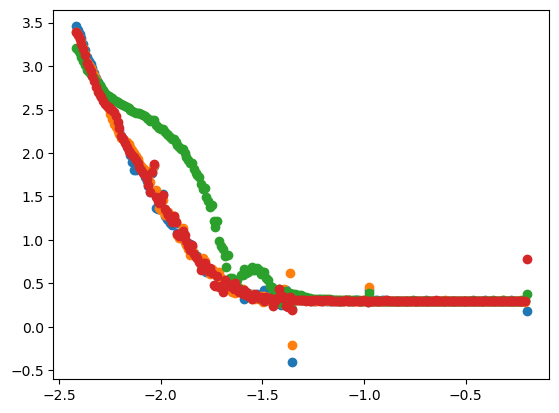

In [18]:
import matplotlib.pyplot as plt 

x = result_dataset["log_q"].to_numpy()
y = result_dataset["log_iq"].to_numpy()
print(x.shape, y.shape)

fig, ax = plt.subplots()
for i in range(result_dataset.sizes["sample"]):
    ax.scatter(x, y[i,:])
plt.show()

# Apply Amplitude-Phase distance as a similarity

In [19]:
from AFL.double_agent.PairMetric import AmplitudePhaseDistance

with my_first_pipeline:
    AmplitudePhaseDistance(
        input_variable="log_q",
        output_variable='similarity',
        sample_dim='log_q',
        )

my_first_pipeline.print()

PipelineOp                               input_variable ---> output_variable
----------                               -----------------------------------
0  ) <PreprocessorBase>                  sas ---> log_iq
1  ) <AmplitudePhaseDistance>            log_q ---> similarity

Input Variables
---------------
0) sas
1) log_q

Output Variables
----------------
0) log_iq
1) similarity


In [20]:
result_dataset = my_first_pipeline.calculate(input_dataset)
result_dataset

  0%|          | 0/2 [00:00<?, ?it/s]

> /Users/kiran/Documents/codebase/AFL-agent/AFL/double_agent/PairMetric.py(538)calculate()
    536 
    537     def calculate(self, dataset: xr.Dataset) -> Self:
--> 538         """Apply this `PipelineOp` to the supplied `xarray.Dataset`"""
    539         pdb.set_trace()
    540         codomain = self._get_variable(dataset).to_numpy()

> /Users/kiran/Documents/codebase/AFL-agent/AFL/double_agent/PairMetric.py(539)calculate()
    537     def calculate(self, dataset: xr.Dataset) -> Self:
    538         """Apply this `PipelineOp` to the supplied `xarray.Dataset`"""
--> 539         pdb.set_trace()
    540         codomain = self._get_variable(dataset).to_numpy()
    541         domain = dataset[self.domain_variable].copy().to_numpy()

<xarray.Dataset> Size: 20kB
Dimensions:  (sample: 4, q: 250, log_q: 250)
Coordinates:
  * q        (q) float64 2kB 0.003836 0.003915 0.003997 ... 0.6079 0.6205 0.6334
  * log_q    (log_q) float64 2kB -2.416 -2.407 -2.398 ... -0.2072 -0.1983
Dimensions with

In [ ]:
result_dataset["similarity"].to_numpy()

array([[0.        , 0.24727606, 1.18102063, 0.1671749 ],
       [0.24727606, 0.        , 1.08664239, 0.12360283],
       [1.18102063, 1.08664239, 0.        , 1.40583533],
       [0.1671749 , 0.12360283, 1.40583533, 0.        ]])